# Credit Risk Prediction

With the increasing adoption of credit cards and digital payment systems, accurate credit risk prediction is essential to manage default risk and promote responsible lending. This project uses the **Default of Credit Card Clients dataset** from the UC Irvine Machine Learning Repository to analyze factors that influence whether a credit card holder will default on their payment.

The dataset provides variables that reflect common assessment factors used by Philippine banks, such as demographic information, credit limits, billing amounts, and past payments.

The goal of this project is to develop a predictive model that determines whether a credit card holder is likely to default on their payment by analyzing patterns in financial behavior and customer characteristics, aiming to support better credit risk assessment and informed decisions.

## Dataset Description

This project uses the **Default of Credit Card Clients Dataset** from the UCI Machine Learning Repository. The dataset contains information on credit card clients and their payment behavior, and it is commonly used for credit risk prediction tasks.

The dataset contains **30,000 observations** with **24 attributes** (23 features, 1 response variable). The attributes are as following:

`X1` or `LIMIT_BAL`: Amount of the given credit (NT dollar), including both the individual consumer credit and his/her family (supplementary credit)

`X2` or `SEX`: Gender of the client (1 = male; 2 = female)

`X3` or `EDUCATION`: Education level (1 = graduate school; 2 = university; 3 = high school; 4 = others)

`X4` or `MARRIAGE`: Marital status (1 = married; 2 = single; 3 = others)

`X5` or `AGE`: Age in years

`X6 - X11` represents the history of past payments from April to September of 2005

| Value | Meaning |
|-------|---------|
| -2    | Client had no bill that month |
| -1    | Paid early / fully paid in advance |
| 0     | Paid on time (no delay) |
| 1     | Payment delayed 1 month |
| 2     | Payment delayed 2 months |
| 3     | Payment delayed 3 months |
| 4     | Payment delayed 4 months |
| 5     | Payment delayed 5 months |
| 6     | Payment delayed 6 months |
| 7     | Payment delayed 7 months |
| 8     | Payment delayed 8 months |
| 9     | Payment delayed 9 months or more |

`X6` or `PAY_0`: Repayment status in September 2005

`X7` or `PAY_2`: Repayment status in August 2005

`X8` or `PAY_3`: Repayment status in July 2005

`X9` or `PAY_4`: Repayment status in June 2005

`X10` or `PAY_5`: Repayment status in May 2005

`X11` or `PAY_6`: Repayment status in April 2005

`X12 - X17` represents the amount of bill statements (NT dollar) from April to September of 2005

`X12` or `BILL_AMT1`: Amount of bill statement in September 2005

`X13` or `BILL_AMT2`: Amount of bill statement in August 2005

`X14` or `BILL_AMT3`: Amount of bill statement in July 2005

`X15` or `BILL_AMT4`: Amount of bill statement in June 2005

`X16` or `BILL_AMT5`: Amount of bill statement in May 2005

`X17` or `BILL_AMT6`: Amount of bill statement in April 2005

`X18 - X23` represents the amount of previous payments (NT dollar) from April to September of 2005

`X18` or `PAY_AMT1`: Amount paid in September 2005

`X19` or `PAY_AMT2`: Amount paid in August 2005

`X20` or `PAY_AMT3`: Amount paid in July 2005

`X21` or `PAY_AMT4`: Amount paid in June 2005

`X22` or `PAY_AMT5`: Amount paid in May 2005

`X23` or `PAY_AMT6`: Amount paid in April 2005

`Y` or `default payment`: Indicates whether the client defaulted on the next payment (1 = yes; 0 = no)

### Imports

In [24]:
import numpy as np
import pandas as pd
import sklearn.preprocessing
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

We will load the dataset from the `.xls` file using **pandas**.
Since the dataset uses `X0` - `X23` and `Y` as the first row, we set `header=1` to correctly load the column names and improve readability.

We can also use `df.head()` to see how the data is structured and encoded.

In [25]:
df = pd.read_excel("default_of_credit_card_clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Exploratory Data Analysis

We will perform EDA to understand feature distributions, detect missing values, and identify any irregularities in the dataset.

In [26]:
# Summary statistics
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


`df.info()` allows us to view the high level information of the dataset.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

With this, we can see that there are no missing values as all columns have 30,000 non-null entries

Let's check for any duplicated rows using `df.duplicated()` and drop them.

In [33]:
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")
df = df.drop_duplicates()
print(f"Number of rows after removing duplicates: {len(df)}")

Number of duplicate rows: 36
Number of rows after removing duplicates: 29964


## Data Cleaning and Preprocessing

Cleaning the data is crucial to avoid errors or unexpected results later on, which may result from data that is inconsistent, incorrect, missing, etc.

Let's drop the `ID` column since it is a unique identifier for each client and does not provide predictive information.

In [29]:
df = df.drop("ID", axis=1)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Standardizing Repayment Status

We will fix the repayment status columns (`PAY_0, PAY_2 – PAY_6`) as follows:  
- `-2` (no bill that month) → 0  
- `-1` (paid duly) → 0  
- 0 and positive integers remain unchanged

This ensures that all on-time payments are represented as 0 and delays remain positive integers.

It's important to note that this presents a risk of data bias as the model may learn that clients with certain features + zero bills are "safe," but this might not be realistic if the zero bill is due to lack of credit activity.

In [30]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
df[pay_cols] = df[pay_cols].replace([-2, -1], 0)
df[pay_cols].head()

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,2,2,0,0,0,0
1,0,2,0,0,0,2
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


### Feature Scaling
#### Standardization

We will perform standardization on the continuous variables in the dataset, such as the bill and payment amounts, using `sklearn.preprocessing.StandardScaler`

In [31]:
scaler = sklearn.preprocessing.StandardScaler()

# Amount columns
amount_cols = [col for col in df.columns if "AMT" in col]

df[amount_cols] = scaler.fit_transform(df[amount_cols])
df[amount_cols].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04,3.000000e+04
mean,-1.231607e-17,-3.789561e-17,6.252776e-17,5.873820e-17,-2.368476e-17,1.136868e-17,-4.736952e-18,1.373716e-17,2.084259e-17,1.800042e-17,-1.965835e-17,-1.788199e-17
std,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00
min,-2.944312e+00,-1.671375e+00,-2.945672e+00,-3.315048e+00,-2.000874e+00,-6.355247e+00,-3.419416e-01,-2.569895e-01,-2.968013e-01,-3.080626e-01,-3.141361e-01,-2.933821e-01
25%,-6.473120e-01,-6.490466e-01,-6.394814e-01,-6.363293e-01,-6.340600e-01,-6.316338e-01,-2.815661e-01,-2.208358e-01,-2.746506e-01,-2.891680e-01,-2.976091e-01,-2.867584e-01
50%,-3.916884e-01,-3.931159e-01,-3.882529e-01,-3.763451e-01,-3.652683e-01,-3.660725e-01,-2.151530e-01,-1.697952e-01,-1.945673e-01,-2.123132e-01,-2.159561e-01,-2.090042e-01
75%,2.154919e-01,2.083271e-01,1.896457e-01,1.747667e-01,1.624955e-01,1.733997e-01,-3.970176e-02,-3.998021e-02,-4.093230e-02,-5.188511e-02,-5.026084e-02,-6.837436e-02
max,1.240296e+01,1.313360e+01,2.331820e+01,1.318669e+01,1.458743e+01,1.549528e+01,5.239921e+01,7.284299e+01,5.059528e+01,3.933218e+01,2.760363e+01,2.944510e+01


We can see that all standardized columns have a mean ≈ 0 and a standard deviation ≈ 1.

Let's visualize the results in two histograms with KDE (Kernel Density Estimate). KDE allows us to visualize the probability distribution more smoothly. We set `bins=30` to divide the data into 30 intervals, providing a clear view of the distribution.

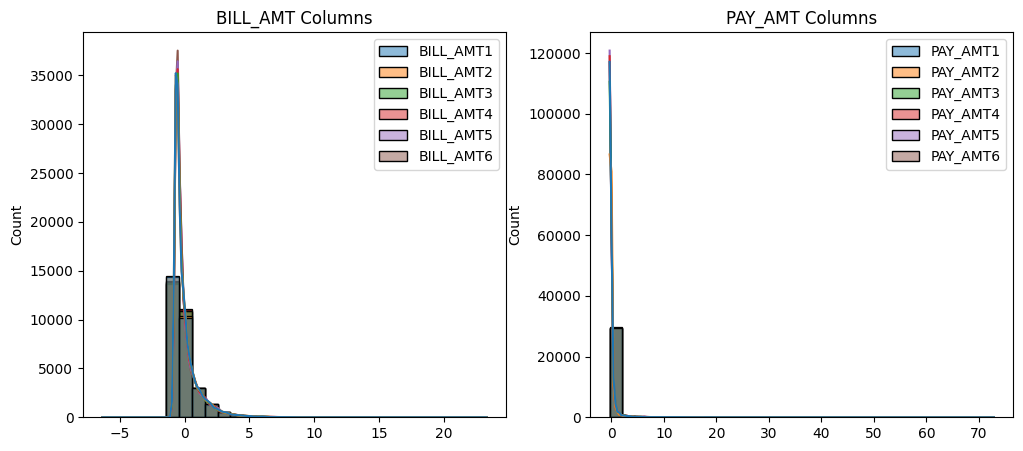

In [32]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df[[col for col in amount_cols if "BILL" in col]], kde=True, bins=30)
plt.title("BILL_AMT Columns")

plt.subplot(1,2,2)
sns.histplot(df[[col for col in amount_cols if "PAY" in col]], kde=True, bins=30)
plt.title("PAY_AMT Columns")

plt.show()

We can see that all columns are centered around 0, as expected after standardization.